In [39]:
# Linear regression in 1D

In [40]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [41]:
X, y, coef = make_regression(n_samples=100,
                         n_features=1, # how many input columns x has
                         n_informative=1, # how many actually matter for predicting y
                         noise=10, # add random distribution
                         coef=True, #  return the true coefficient it used to generate the data.
                         random_state=0, # The noise is random — but if you set a seed,  0 for identical data
                         bias=100.0) # Without it the line would pass through the origin

In [42]:
## plot the raw data

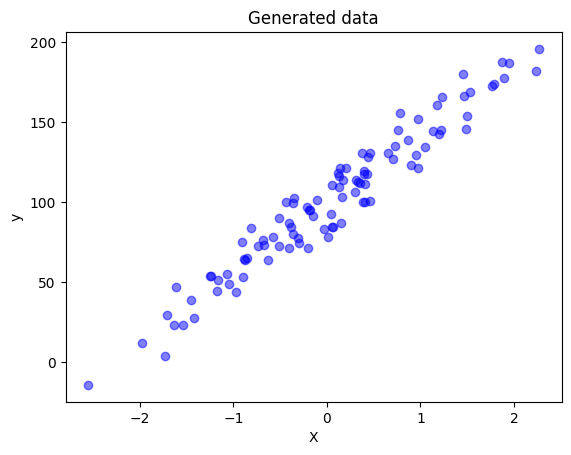

In [43]:
plt.scatter(X, y, color='blue', alpha=0.5)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Generated data")
plt.show()

In [44]:
from sklearn.linear_model import LinearRegression

In [45]:
model = LinearRegression()
model.fit(X, y)

print(f"y = {model.coef_[0]:.2f} * x + {model.intercept_:.2f}")

y = 42.62 * x + 99.19


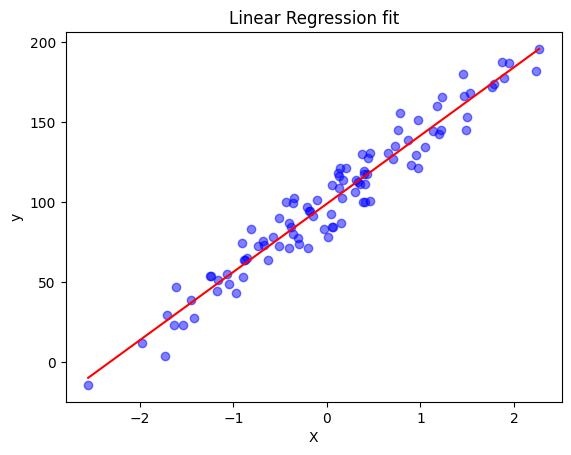

In [46]:
x_line = np.linspace(X.min(), X.max(), 100) # how many points to generate in between
# -1 -> I don't want to calculate this dimension, you do it.
y_line = model.predict(x_line.reshape(-1, 1)) # flat row of 100 numbers.

plt.scatter(X, y, color='blue', alpha=0.5)
plt.plot(x_line, y_line, color='red')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression fit")
plt.show()

In [ ]:
#  predict on X

In [38]:
y_pred = model.predict(X)
print(y_pred)

[ 83.86186727 140.80961751 116.3333897   64.52998689  61.34889539
 118.10301628  57.5347917  117.44107847 108.06237908  85.90762675
  77.41559422 104.59473926  33.71198748  82.06214357 127.04267034
 149.42473193  91.51752418 175.2986012  161.16612653  69.99960224
 140.89907346 179.98753475  80.51534101 112.52858526 131.62081245
 132.3220142  182.32675414 113.40682791  84.35800058 164.51199505
  61.02154349  74.51557524  54.49708817 115.30288932  99.63332307
 118.90933425 105.32487311  82.00264639 101.39970135  45.79239366
 144.12595004 116.24029042  26.46555473 194.69140967 106.74761927
  90.44208985 151.62010608  62.78474435 174.36872416 116.6852924
  60.51727878  38.66546269 119.03208606 137.57852984 147.74642622
 116.31837583 115.67538221  25.61263714 161.80905184  91.20814913
  62.07293978 112.07699813 150.43056232  14.76540117  -9.62115332
  37.20158169  97.98470766 105.78958918 151.28573064 178.78007575
 195.92146715  67.55516782 102.0207443  162.86261708  70.525937
  29.70769336

In [ ]:
#  MSE function

In [47]:
def compute_mse(y_true, y_pred):
    mse = np.mean((y_pred - y_true) ** 2)
    return mse

print("MSE:", compute_mse(y, y_pred))

MSE: 114.17148616819486


In [ ]:
# change noise to 50, repeat:

In [48]:
X_noisy, y_noisy, coef_noisy = make_regression(n_samples=100,
                                                n_features=1,
                                                n_informative=1,
                                                noise=50,
                                                coef=True,
                                                random_state=0,
                                                bias=100.0)

model_noisy = LinearRegression()
model_noisy.fit(X_noisy, y_noisy)

print(f"y = {model_noisy.coef_[0]:.2f} * x + {model_noisy.intercept_:.2f}")

y_pred_noisy = model_noisy.predict(X_noisy)
print("MSE:", compute_mse(y_noisy, y_pred_noisy))

y = 43.56 * x + 95.93
MSE: 2854.2871542048706


In [63]:
# Forecast diabetes progression

In [64]:
from sklearn.datasets import load_diabetes
import pandas as pd

In [66]:
diabetes = load_diabetes(as_frame=True)
X, y = diabetes.data, diabetes.target

In [68]:
# bmi -> body mass index
print(X.shape)
print(y.shape)
print(X.head())
print(y.describe())

(442, 10)
(442,)
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  
count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64


In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (353, 10)
Test size: (89, 10)


In [73]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_) # the b in the equation. 
print("Coefficients:")

for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.2f}")

Intercept: 152.0532454782767
Coefficients:
  age: -60.40
  sex: -226.08
  bmi: 529.38
  bp: 259.96
  s1: -859.09
  s2: 504.69
  s3: 157.41
  s4: 226.29
  s5: 840.78
  s6: 34.71


In [76]:
y_pred = model.predict(X_test)

In [77]:
print("Train MSE:", compute_mse(y_train, model.predict(X_train)))
print("Test MSE:", compute_mse(y_test, y_pred))

Train MSE: 2888.324598377127
Test MSE: 2858.2915057597897
